# Shark Electroreception: Vector Calculus in a Real Biological Sensor

The ampullae of Lorenzini are the most sensitive biological electric-field
detectors known -- widely cited (Kalmijn, 1971) as able to resolve fields
as small as **5 nV/cm**. This notebook checks two real hypotheses about
what they're used for, and one mechanism for HOW they localize a source,
using three pieces of vector calculus already built elsewhere this
session on unrelated examples:

1. **Geomagnetic navigation** (Kalmijn's induction hypothesis): a swimming
   shark's motion through Earth's magnetic field induces an electric field
   via $\mathbf E=\mathbf v\times\mathbf B$ -- is that field actually
   above the detection threshold?
2. **Prey detection**: a nearby prey's weak bioelectric field, modeled as
   an electric dipole -- the exact Griffiths dipole-field formula.
3. **Directional sensing**: the ampullae are distributed across the
   snout, not one point sensor -- a small array's estimated FIELD
   GRADIENT (the same idea from this session's AP-Calc study note) should
   point toward the true source.

Engine: `dgs/shark_electroreception.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs import shark_electroreception as se

print('Setup complete.')


Setup complete.


## 1. Kalmijn's Geomagnetic-Induction Hypothesis

$\mathbf E = \mathbf v\times\mathbf B$: is the induced field, from a
realistic cruising speed through Earth's field, actually above the cited
detection threshold?


In [2]:
result = se.verify_geomagnetic_sensing_plausible(swim_speed_m_s=1.0, B_earth_T=50e-6)
print(f"swimming at 1.0 m/s through a 50uT field (perpendicular):")
print(f"  induced field = {result['E_field_V_per_m']:.2e} V/m = {result['field_nV_per_cm']:.1f} nV/cm")
print(f"  Kalmijn's cited threshold = {result['threshold_nV_per_cm']} nV/cm")
print(f"  detectable: {result['detectable']}  (margin: {result['margin_factor']:.0f}x threshold)")


swimming at 1.0 m/s through a 50uT field (perpendicular):
  induced field = 5.00e-05 V/m = 500.0 nV/cm
  Kalmijn's cited threshold = 5.0 nV/cm
  detectable: True  (margin: 100x threshold)


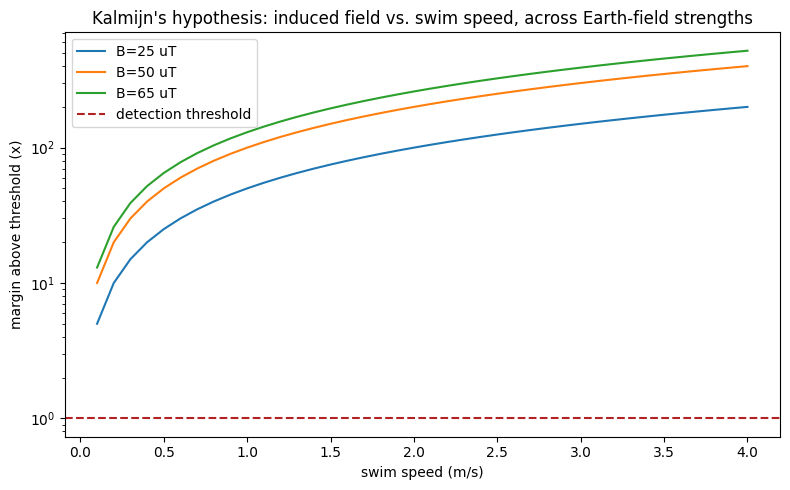

In [3]:
speeds = np.linspace(0.1, 4.0, 40)
fields_B = [25e-6, 50e-6, 65e-6]

fig, ax = plt.subplots(figsize=(8, 5))
for B in fields_B:
    margins = [se.verify_geomagnetic_sensing_plausible(v, B)['margin_factor'] for v in speeds]
    ax.plot(speeds, margins, label=f'B={B*1e6:.0f} uT')
ax.axhline(1.0, color='firebrick', ls='--', label='detection threshold')
ax.set_xlabel('swim speed (m/s)'); ax.set_ylabel('margin above threshold (x)')
ax.set_yscale('log')
ax.set_title("Kalmijn's hypothesis: induced field vs. swim speed, across Earth-field strengths")
ax.legend()
plt.tight_layout()
plt.savefig('shark_geomagnetic_margin.png', dpi=100, bbox_inches='tight')
plt.show()


## 2. Prey Detection: the Exact Dipole Field

$|E(r,\theta)|=\frac{p}{4\pi\varepsilon_0 r^3}\sqrt{1+3\cos^2\theta}$
-- on-axis is EXACTLY 2x the equatorial field, checked directly.


In [4]:
check = se.verify_dipole_axis_ratio()
print(f"on-axis field:   {check['on_axis_V_per_m']:.4e} V/m")
print(f"equatorial field: {check['equatorial_V_per_m']:.4e} V/m")
print(f"ratio: {check['ratio']:.6f}  (exact theory: 2.0, matches: {check['matches_theory']})")


on-axis field:   1.7975e+01 V/m
equatorial field: 8.9876e+00 V/m
ratio: 2.000000  (exact theory: 2.0, matches: True)


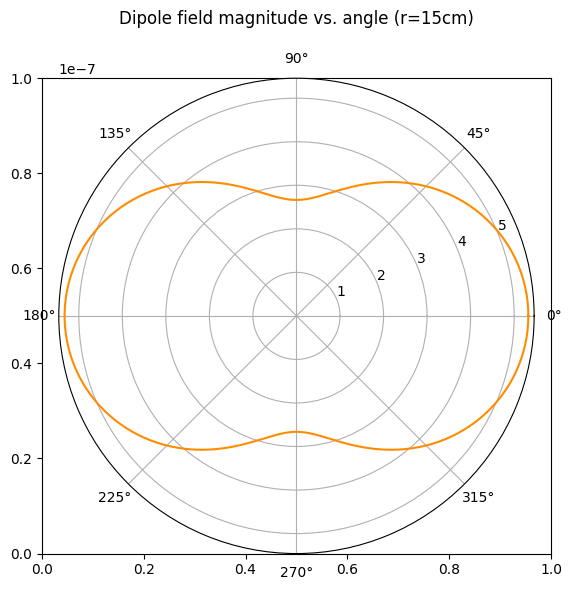

In [5]:
theta = np.linspace(0, 2*np.pi, 200)
p, r = 1e-19, 0.15
E_vals = [se.dipole_field_magnitude(p, r, t) for t in theta]

fig = plt.subplots(figsize=(6, 6))
ax = plt.subplot(projection='polar')
ax.plot(theta, E_vals, color='darkorange')
ax.set_title('Dipole field magnitude vs. angle (r=15cm)', pad=20)
plt.tight_layout()
plt.savefig('shark_dipole_polar.png', dpi=100, bbox_inches='tight')
plt.show()


**Detection range** is shown for a few ILLUSTRATIVE dipole strengths
(chosen to land in the tens-of-cm ballpark commonly cited for shark prey
detection, not a specific cited biological measurement -- real prey
source strengths belong to the primary literature, Kalmijn 1971/1982).


p=3e-20 C*m: on-axis detection range = 10.3 cm
p=1e-19 C*m: on-axis detection range = 15.3 cm
p=3e-19 C*m: on-axis detection range = 22.1 cm
p=1e-18 C*m: on-axis detection range = 33.0 cm


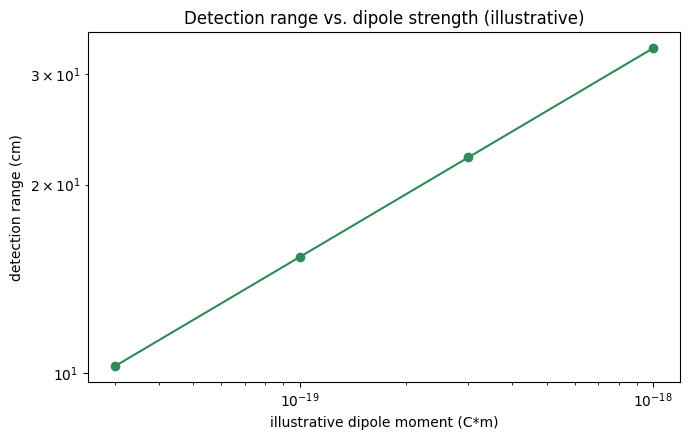

In [6]:
p_values = np.array([3e-20, 1e-19, 3e-19, 1e-18])
ranges_cm = [se.detection_range_on_axis(p) * 100 for p in p_values]
for p, r in zip(p_values, ranges_cm):
    print(f'p={p:.0e} C*m: on-axis detection range = {r:.1f} cm')

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(p_values, ranges_cm, 'o-', color='seagreen')
ax.set_xlabel('illustrative dipole moment (C*m)'); ax.set_ylabel('detection range (cm)')
ax.set_title('Detection range vs. dipole strength (illustrative)')
plt.tight_layout()
plt.savefig('shark_detection_range.png', dpi=100, bbox_inches='tight')
plt.show()


## 3. Directional Sensing: Gradient From a Distributed Array

The ampullae are spread across the snout. A small grid of sample points
estimates the field GRADIENT via least squares -- verified to point
toward the true source direction.


In [7]:
check = se.verify_gradient_points_to_source(source_pos=(1.0, 0.4, -0.2))
print(f"estimated gradient (y,z): {check['estimated_gradient_yz']}")
print(f"true gradient (y,z):      {check['true_gradient_yz']}")
print(f"cosine similarity: {check['cosine_similarity']:.7f}  (angle error: {check['angle_error_deg']:.4f} deg)")
print(f"well aligned: {check['well_aligned']}")


estimated gradient (y,z): [ 2.69521309 -1.34964733]
true gradient (y,z):      [ 2.73482492 -1.36741246]
cosine similarity: 0.9999998  (angle error: 0.0347 deg)
well aligned: True


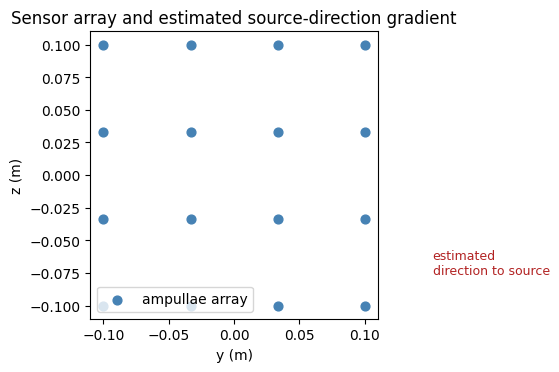

In [8]:
sensor_positions = se.ampullae_array_positions(half_width_m=0.1, n_per_axis=4)
source_pos = np.array([1.0, 0.4, -0.2])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(sensor_positions[:, 1], sensor_positions[:, 2], color='steelblue', s=40, label='ampullae array')
est = check['estimated_gradient_yz'] / np.linalg.norm(check['estimated_gradient_yz'])
ax.annotate('', xy=(est[0]*0.15, est[1]*0.15), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='firebrick', lw=2))
ax.text(est[0]*0.17, est[1]*0.17, 'estimated\ndirection to source', color='firebrick', fontsize=9)
ax.set_xlabel('y (m)'); ax.set_ylabel('z (m)')
ax.set_aspect('equal')
ax.set_title('Sensor array and estimated source-direction gradient')
ax.legend(loc='lower left')
plt.tight_layout()
plt.savefig('shark_array_gradient.png', dpi=100, bbox_inches='tight')
plt.show()


In [9]:
for n in (2, 3, 4, 6, 8):
    c = se.verify_gradient_points_to_source(n_per_axis=n)
    print(f'n_per_axis={n}: angle error = {c["angle_error_deg"]:.4f} deg')


n_per_axis=2: angle error = 0.0927 deg
n_per_axis=3: angle error = 0.0458 deg
n_per_axis=4: angle error = 0.0347 deg
n_per_axis=6: angle error = 0.0273 deg
n_per_axis=8: angle error = 0.0245 deg


## 4. Engineering Interpretation

- Section 1's margin (tens to hundreds of times above threshold across
  realistic speeds and field strengths) is the actual numerical basis for
  taking Kalmijn's hypothesis seriously as a physically plausible
  mechanism -- not just "sharks are sensitive, so maybe."
- Section 2's exact on-axis/equatorial ratio check matters because it's
  the kind of identity that's easy to get subtly wrong (a sign error, a
  factor of 2) while still producing plausible-looking numbers -- checking
  it against the known-exact 2.0 catches that class of bug immediately.
- Section 3's array-gradient approach is a genuine engineering pattern
  beyond biology: any distributed sensor array (electric field, magnetic
  field, or otherwise) localizes a source the same way -- fit a local
  linear model to the sampled measurements, read off the gradient. The
  bio-inspired framing and the engineering technique are the same
  mathematics, not just an analogy.


## 5. Research Discussion

- This module uses vacuum permittivity (`EPS0`) throughout; seawater's
  relative permittivity is much higher (~80) and it's conductive (not a
  pure dielectric), so a physically faithful model of the actual
  in-water field would need the full electroquasistatic treatment in a
  conducting medium, not the vacuum dipole formula -- a real and
  significant caveat this notebook doesn't currently address.
- `dgs.irrotational_solenoidal_polyglot`'s point-charge example field IS
  `point_charge_field_vector` here, just with the source moved off the
  origin -- worth an explicit note connecting the two rather than leaving
  the reader to notice the reuse independently.
- Section 3's array-gradient technique is exactly how a real engineered
  gradiometer (used in magnetic anomaly detection, geophysical surveying)
  localizes a source -- a genuine bio-inspired-sensor-design angle worth
  developing further, beyond just verifying the biological hypothesis.


## 6. Possible Experiments

1. Add seawater's relative permittivity (eps_r ~ 80) to the dipole-field
   formula and see how much the illustrative detection ranges in Section
   2 shift -- a first-order correction toward physical realism.
2. Vary the array's `half_width_m` (representing different shark head
   sizes/species) and quantify how directional-sensing accuracy
   (Section 3's angle error) depends on the array's physical span.
3. Add sensor noise (small random perturbations to each sampled
   potential) and find how much noise the gradient estimate tolerates
   before `well_aligned` starts failing -- a realistic robustness check a
   pure noiseless calculation can't show.


## 7. Future Improvements

- `dipole_field_magnitude`'s vacuum-permittivity assumption (noted in
  Section 5) is the most significant physical gap -- a conducting-medium
  (seawater) treatment would change both the field's spatial falloff and
  its effective source strength.
- `ampullae_array_positions`'s flat 2-D grid is a simplification; real
  ampullae are distributed over a curved snout surface with non-uniform
  density -- a more anatomically realistic point distribution would be a
  natural extension.
